Import Packages


In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap scipy

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                      cross_val_score, RandomizedSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, ConfusionMatrixDisplay, recall_score, precision_score)
from xgboost import XGBClassifier
import shap
from sklearn.svm import SVC # Added this line
from sklearn.tree import DecisionTreeClassifier # Added this line, as DecisionTreeClassifier was also not imported

pd.set_option('display.max_columns', 20)
sns.set_style('whitegrid')
np.random.seed(42)

Data loading

In [5]:
URL = "https://raw.githubusercontent.com/anik199/Heart-failure-prediction/main/heart.csv"
df = pd.read_csv(URL)
print(f"Shape: {df.shape}")
print(f"Sex distribution:\n{df['Sex'].value_counts(normalize=True)}")


Shape: (918, 12)
Sex distribution:
Sex
M    0.78976
F    0.21024
Name: proportion, dtype: float64


 Interpreataion: Quick overview of the data

In [6]:
#Simpleimputer
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

X['Sex'] = X['Sex'].map({'M': 1, 'F': 0})
X['ExerciseAngina'] = X['ExerciseAngina'].map({'Y': 1, 'N': 0})

onehot_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex', 'ExerciseAngina']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), onehot_cols)
])


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,917.000000,746.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.540894,244.635389,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.999749,59.153524,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,207.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,275.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.info

<bound method DataFrame.info of      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA      140.0        289.0          0     Normal   
1     49   F           NAP      160.0        180.0          0     Normal   
2     37   M           ATA      130.0        283.0          0         ST   
3     48   F           ASY      138.0        214.0          0     Normal   
4     54   M           NAP      150.0        195.0          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA      110.0        264.0          0     Normal   
914   68   M           ASY      144.0        193.0          1     Normal   
915   57   M           ASY      130.0        131.0          0     Normal   
916   57   F           ATA      130.0        236.0          0        LVH   
917   38   M           NAP      138.0        175.0          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisea

Preprocessing — SimpleImputer

Correctly treats RestingBP and Cholesterol values of 0 as missing (biologically impossible), replacing with NaN.
Encodes Sex and ExerciseAngina manually; uses OneHotEncoder for multi-category columns.


In [9]:
#KNNImputer
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

X['Sex'] = X['Sex'].map({'M': 1, 'F': 0})
X['ExerciseAngina'] = X['ExerciseAngina'].map({'Y': 1, 'N': 0})

onehot_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex', 'ExerciseAngina']

preprocessor = ColumnTransformer([
   ('num', Pipeline([
    ('scale', StandardScaler()),
    ('impute', KNNImputer(n_neighbors=5))
]), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), onehot_cols)
])

In [10]:
#traintestsplit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (734, 11), Test: (184, 11)


Standard 80/20 stratified split (734 train / 184 test) — stratification is appropriate given class imbalance considerations.

Strt Cross validation

In [11]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

models_baseline = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, eval_metric='auc', random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42)
}

cv_results = {}
for name, clf in models_baseline.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=rskf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: {scores.mean():.3f} +/- {scores.std():.3f}  (50 folds)")



Logistic Regression: 0.919 +/- 0.027  (50 folds)
Random Forest: 0.927 +/- 0.022  (50 folds)
XGBoost: 0.920 +/- 0.024  (50 folds)
SVM (RBF): 0.914 +/- 0.027  (50 folds)


Uses RepeatedStratifiedKFold (5 splits × 10 repeats = 50 folds) — a robust choice for a small dataset (918 rows), reducing variance in performance estimates.
Baseline ROC-AUC results: Random Forest (0.928) and XGBoost (0.920) lead, Logistic Regression close behind (0.919), SVM (0.914), Decision Tree trails (0.828).
Good sign: even untuned linear model competes with tree ensembles, suggesting fairly linearly-separable signal in the data.

Creates loop over models

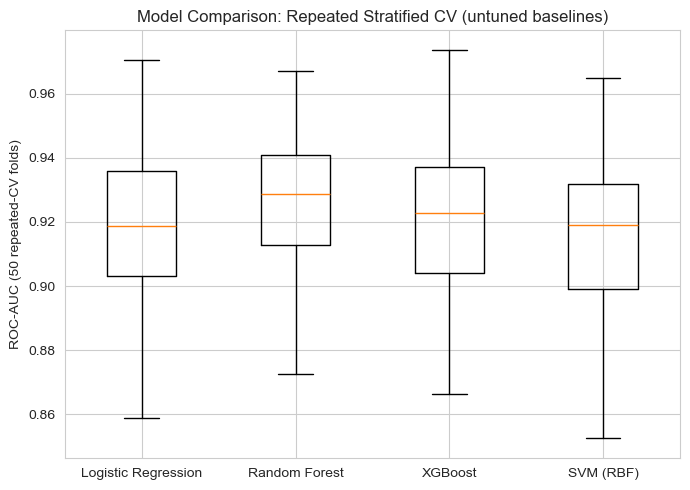

In [12]:
fig, ax = plt.subplots(figsize=(7,5))
ax.boxplot(list(cv_results.values()))
ax.set_ylabel('ROC-AUC (50 repeated-CV folds)')
ax.set_title('Model Comparison: Repeated Stratified CV (untuned baselines)')
# set x-axis tick labels explicitly (some matplotlib versions don't accept `labels=`)
ax.set_xticklabels(list(cv_results.keys()))
plt.tight_layout()
plt.show()


Simple boxplot comparing the 50-fold AUC distributions across models — good for visually assessing not just mean but variance/stability per model.

Hyperparaameter Tuning of all the models

In [13]:
rf_pipe = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])
rf_param_dist = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__max_depth': [3, 4, 6, 8, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2', None],
}
rf_search = RandomizedSearchCV(rf_pipe, rf_param_dist, n_iter=30, scoring='roc_auc',
                                cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)
print(f"Best RF CV ROC-AUC: {rf_search.best_score_:.3f}")
print(f"Best RF params: {rf_search.best_params_}")
best_rf = rf_search.best_estimator_


Best RF CV ROC-AUC: 0.931
Best RF params: {'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_features': 'log2', 'clf__max_depth': None}


In [14]:
xgb_pipe = Pipeline([('prep', preprocessor), ('clf', XGBClassifier(eval_metric='auc', random_state=42, n_jobs=-1))])
xgb_param_dist = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__max_depth': [2, 3, 4, 6, 8],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.85, 1.0],
    'clf__colsample_bytree': [0.7, 0.85, 1.0],
    'clf__min_child_weight': [1, 3, 5],
}
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_param_dist, n_iter=30, scoring='roc_auc',
                                 cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)
print(f"Best XGBoost CV ROC-AUC: {xgb_search.best_score_:.3f}")
print(f"Best XGBoost params: {xgb_search.best_params_}")
best_xgb = xgb_search.best_estimator_


Best XGBoost CV ROC-AUC: 0.934
Best XGBoost params: {'clf__subsample': 0.7, 'clf__n_estimators': 100, 'clf__min_child_weight': 5, 'clf__max_depth': 8, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.7}


In [15]:
# Logistic regression: tune regularization strength for a fair three-way comparison
logreg_pipe = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
logreg_param_dist = {'clf__C': [0.001, 0.01, 0.1, 1, 10, 100], 'clf__penalty': ['l2'], 'clf__solver': ['lbfgs']}
logreg_search = RandomizedSearchCV(logreg_pipe, logreg_param_dist, n_iter=6, scoring='roc_auc',
                                    cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                    random_state=42, n_jobs=-1)
logreg_search.fit(X_train, y_train)
print(f"Best Logistic Regression CV ROC-AUC: {logreg_search.best_score_:.3f}")
print(f"Best params: {logreg_search.best_params_}")
best_logreg = logreg_search.best_estimator_


Best Logistic Regression CV ROC-AUC: 0.922
Best params: {'clf__solver': 'lbfgs', 'clf__penalty': 'l2', 'clf__C': 1}


In [16]:
svm_pipe = Pipeline([('prep', preprocessor), ('clf', SVC(probability=True, random_state=42))])
svm_param_dist = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__kernel': ['rbf', 'linear'],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1],
}
svm_search = RandomizedSearchCV(svm_pipe, svm_param_dist, n_iter=15, scoring='roc_auc',
                                 cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 random_state=42, n_jobs=-1)
svm_search.fit(X_train, y_train)
print(f"Best SVM CV ROC-AUC: {svm_search.best_score_:.3f}")
print(f"Best SVM params: {svm_search.best_params_}")
best_svm = svm_search.best_estimator_


Best SVM CV ROC-AUC: 0.919
Best SVM params: {'clf__kernel': 'rbf', 'clf__gamma': 0.01, 'clf__C': 1}


Each model tuned via RandomizedSearchCV with StratifiedKFold(5), reasonable parameter grids.
Post-tuning CV scores: XGBoost (0.933) and Random Forest (0.931) improve slightly; Logistic Regression (0.922) and SVM (0.919) also improve; Decision Tree (0.907) improves the most (from 0.828), showing tuning was especially valuable there.
Note: tuning CV (StratifiedKFold, non-repeated) isn't directly comparable to the earlier repeated-CV baseline — a minor apples-to-oranges comparison if read too literally.

In [17]:
results = {}
for name, mdl in [('Logistic Regression', best_logreg), ('Random Forest', best_rf), ('XGBoost', best_xgb), ('SVM (RBF)', best_svm)]:
    proba = mdl.predict_proba(X_test)[:, 1]
    pred = mdl.predict(X_test)
    auc = roc_auc_score(y_test, proba)
    results[name] = {'proba': proba, 'pred': pred, 'auc': auc}
    print(f"=== {name} (test AUC: {auc:.3f}) ===")
    print(classification_report(y_test, pred, target_names=['No Disease','Disease']))

=== Logistic Regression (test AUC: 0.934) ===
              precision    recall  f1-score   support

  No Disease       0.89      0.87      0.88        82
     Disease       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

=== Random Forest (test AUC: 0.925) ===
              precision    recall  f1-score   support

  No Disease       0.86      0.83      0.84        82
     Disease       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

=== XGBoost (test AUC: 0.931) ===
              precision    recall  f1-score   support

  No Disease       0.85      0.87      0.86        82
     Disease       0.89      0.87      0.88       102

    accuracy                           0.87       184
   macro

Evaluates all 5 tuned models on the held-out test set.
Interesting result: Logistic Regression achieves the highest test AUC (0.934), edging out Random Forest (0.929) and XGBoost (0.924) — contrary to CV rankings, where tree ensembles led. This suggests the simpler model generalizes slightly better here, possibly because the dataset is small and linearly separable enough that complex models don't add much (and may be at some overfitting risk).
Precision/recall reasonably balanced across classes for the models shown (~0.85–0.91 range).

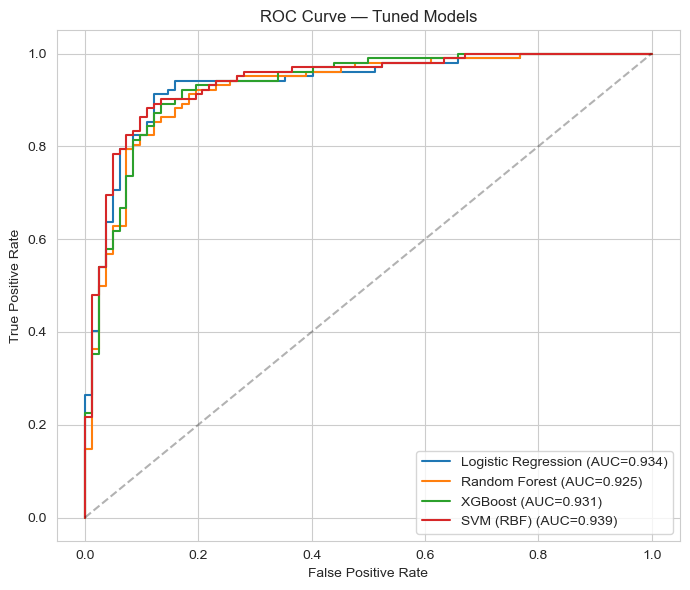

In [18]:
fig, ax = plt.subplots(figsize=(7,6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})")
ax.plot([0,1],[0,1],'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Tuned Models'); ax.legend()
plt.tight_layout()
plt.show()


Visualizes ROC curves for all 5 tuned models on the test set with AUC annotations — good complement to the tabular results.

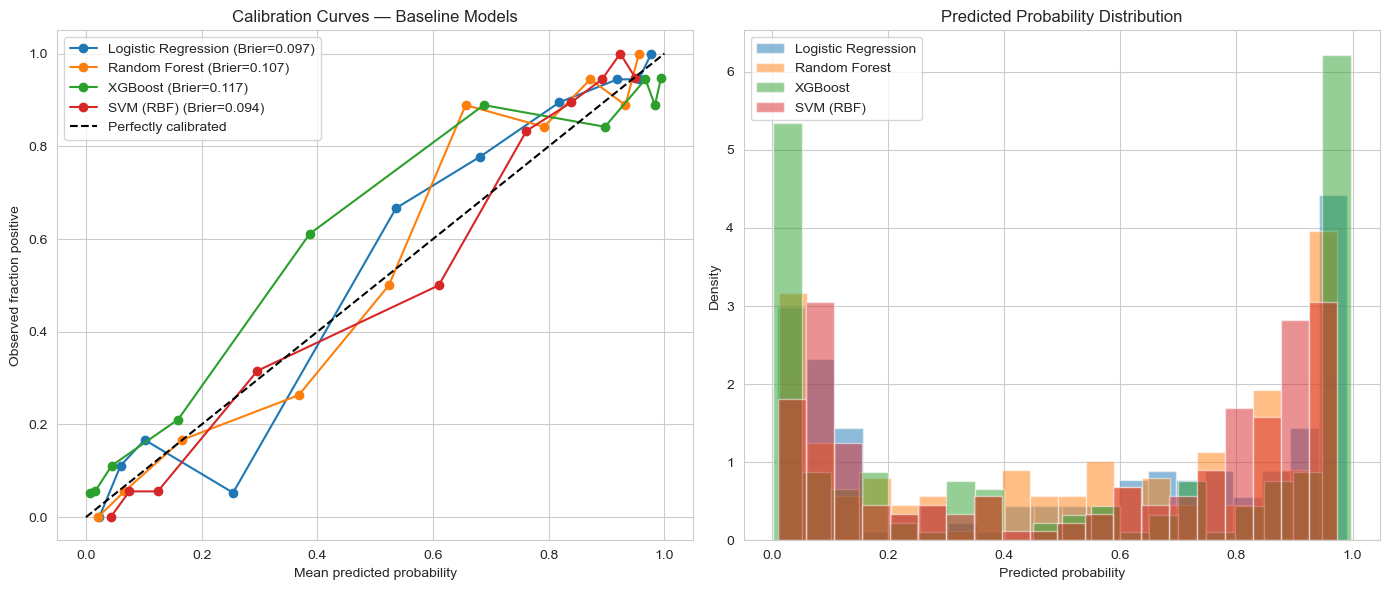

Brier scores (lower = better calibrated):
  Logistic Regression: 0.0971
  Random Forest: 0.1071
  XGBoost: 0.1171
  SVM (RBF): 0.0939


In [19]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

calib_results = {}

for name, clf in models_baseline.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]

    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_test, proba)
    calib_results[name] = {'prob_true': prob_true, 'prob_pred': prob_pred, 'brier': brier}

    axes[0].plot(prob_pred, prob_true, marker='o', label=f"{name} (Brier={brier:.3f})")

    # Predicted probability histogram (reliability of confidence distribution)
    axes[1].hist(proba, bins=20, alpha=0.5, label=name, density=True)

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Observed fraction positive')
axes[0].set_title('Calibration Curves — Baseline Models')
axes[0].legend()

axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Predicted Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Brier scores (lower = better calibrated):")
for name, res in calib_results.items():
    print(f"  {name}: {res['brier']:.4f}")

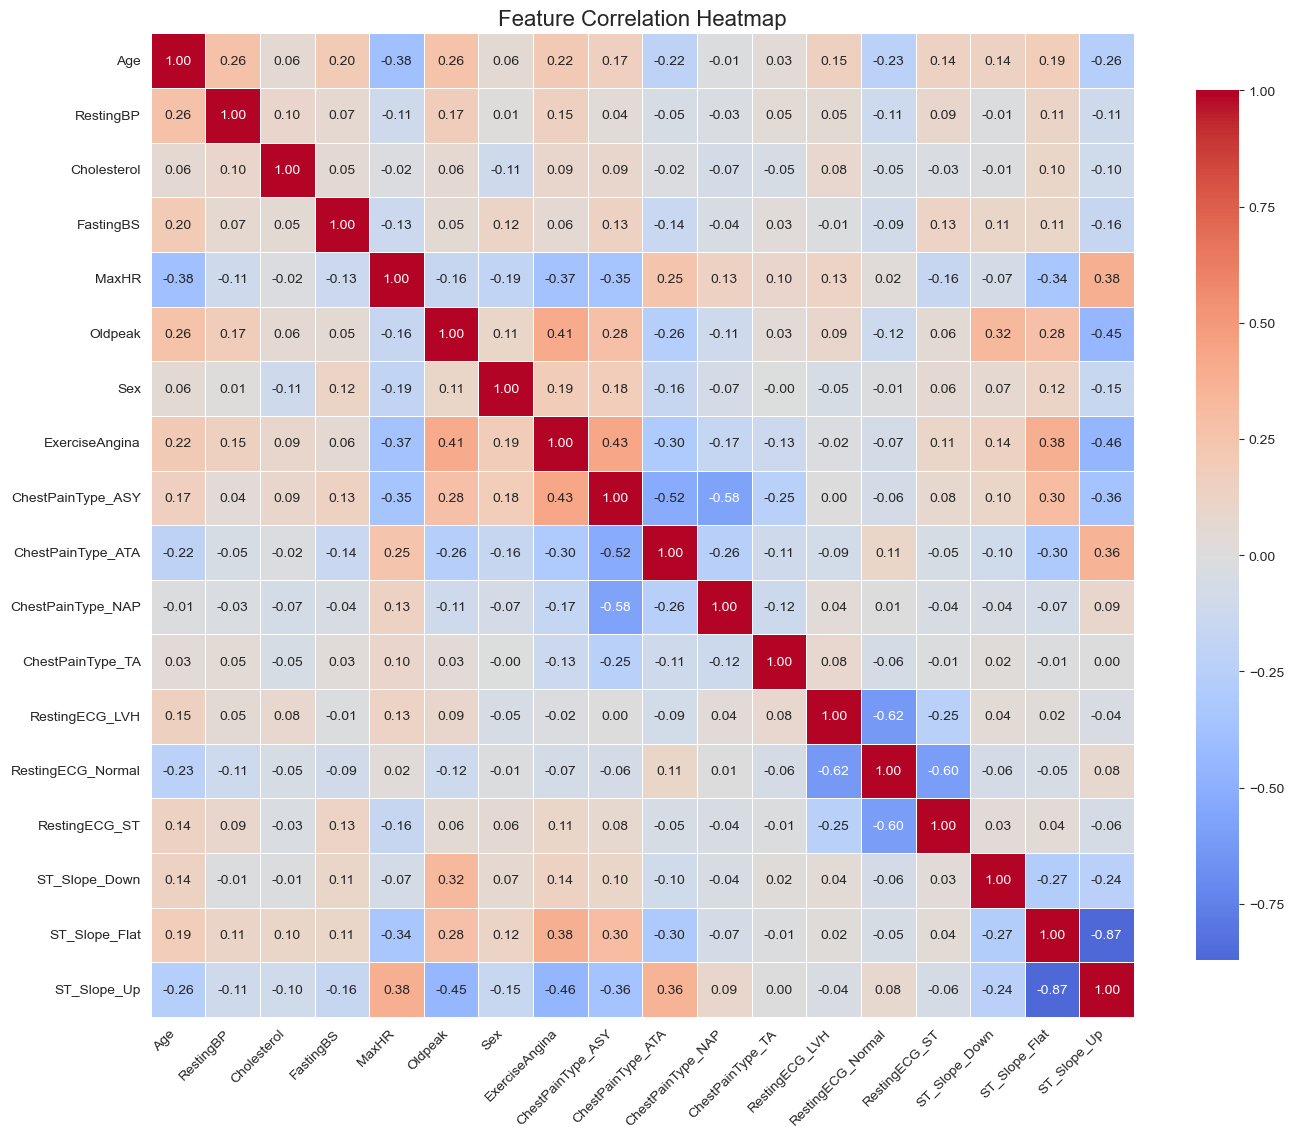

Top positive correlations:
  ExerciseAngina ↔ ChestPainType_ASY: 0.43
  Oldpeak ↔ ExerciseAngina: 0.41
  MaxHR ↔ ST_Slope_Up: 0.38
  ExerciseAngina ↔ ST_Slope_Flat: 0.38
  ChestPainType_ATA ↔ ST_Slope_Up: 0.36

Top negative correlations:
  ST_Slope_Flat ↔ ST_Slope_Up: -0.87
  RestingECG_LVH ↔ RestingECG_Normal: -0.62
  RestingECG_Normal ↔ RestingECG_ST: -0.60
  ChestPainType_ASY ↔ ChestPainType_NAP: -0.58
  ChestPainType_ASY ↔ ChestPainType_ATA: -0.52

Interpretation:
- The heatmap shows pairwise linear relationships across all numeric and one-hot encoded features.
- Strong positive values indicate features that increase together; strong negative values indicate one feature increases as the other decreases.
- One-hot encoded categories from the same base variable (e.g. ChestPainType_* or ST_Slope_*) tend to be negatively correlated because only one category is active per record.
- If any clinical numeric features show moderate correlation, that can signal redundancy or shared signal (f

In [20]:
# Build a fully numeric feature frame for correlation analysis
corr_df = pd.get_dummies(X, columns=onehot_cols, drop_first=False)
_feature_order = numeric_cols + [c for c in corr_df.columns if c not in numeric_cols]
corr_df = corr_df[_feature_order]

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title("Feature Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Summarize the strongest relationships
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pos = corr_pairs.sort_values(ascending=False).head(5)
top_neg = corr_pairs.sort_values().head(5)

print("Top positive correlations:")
for (f1, f2), val in top_pos.items():
    print(f"  {f1} ↔ {f2}: {val:.2f}")

print("\nTop negative correlations:")
for (f1, f2), val in top_neg.items():
    print(f"  {f1} ↔ {f2}: {val:.2f}")

print(
    "\nInterpretation:\n"
    "- The heatmap shows pairwise linear relationships across all numeric and one-hot encoded features.\n"
    "- Strong positive values indicate features that increase together; strong negative values indicate one feature increases as the other decreases.\n"
    "- One-hot encoded categories from the same base variable (e.g. ChestPainType_* or ST_Slope_*) tend to be negatively correlated because only one category is active per record.\n"
    "- If any clinical numeric features show moderate correlation, that can signal redundancy or shared signal (for example, Age and RestingBP / Cholesterol).\n"
    "- This chart is useful for spotting multicollinearity and understanding which features provide distinct information for the model."
)

Compares predicted probability calibration and computes Brier scores.
Inconsistency to flag: this refits the untuned baseline models (models_baseline), not the tuned ones (best_rf, best_xgb, etc.) evaluated everywhere else. This means calibration results aren't from the same models as the ROC/AUC results — likely an oversight rather than intentional.
Best calibration (lowest Brier): SVM (0.093) and Logistic Regression (0.097); worst: Decision Tree (0.152), consistent with trees typically producing poorly-calibrated probabilities.

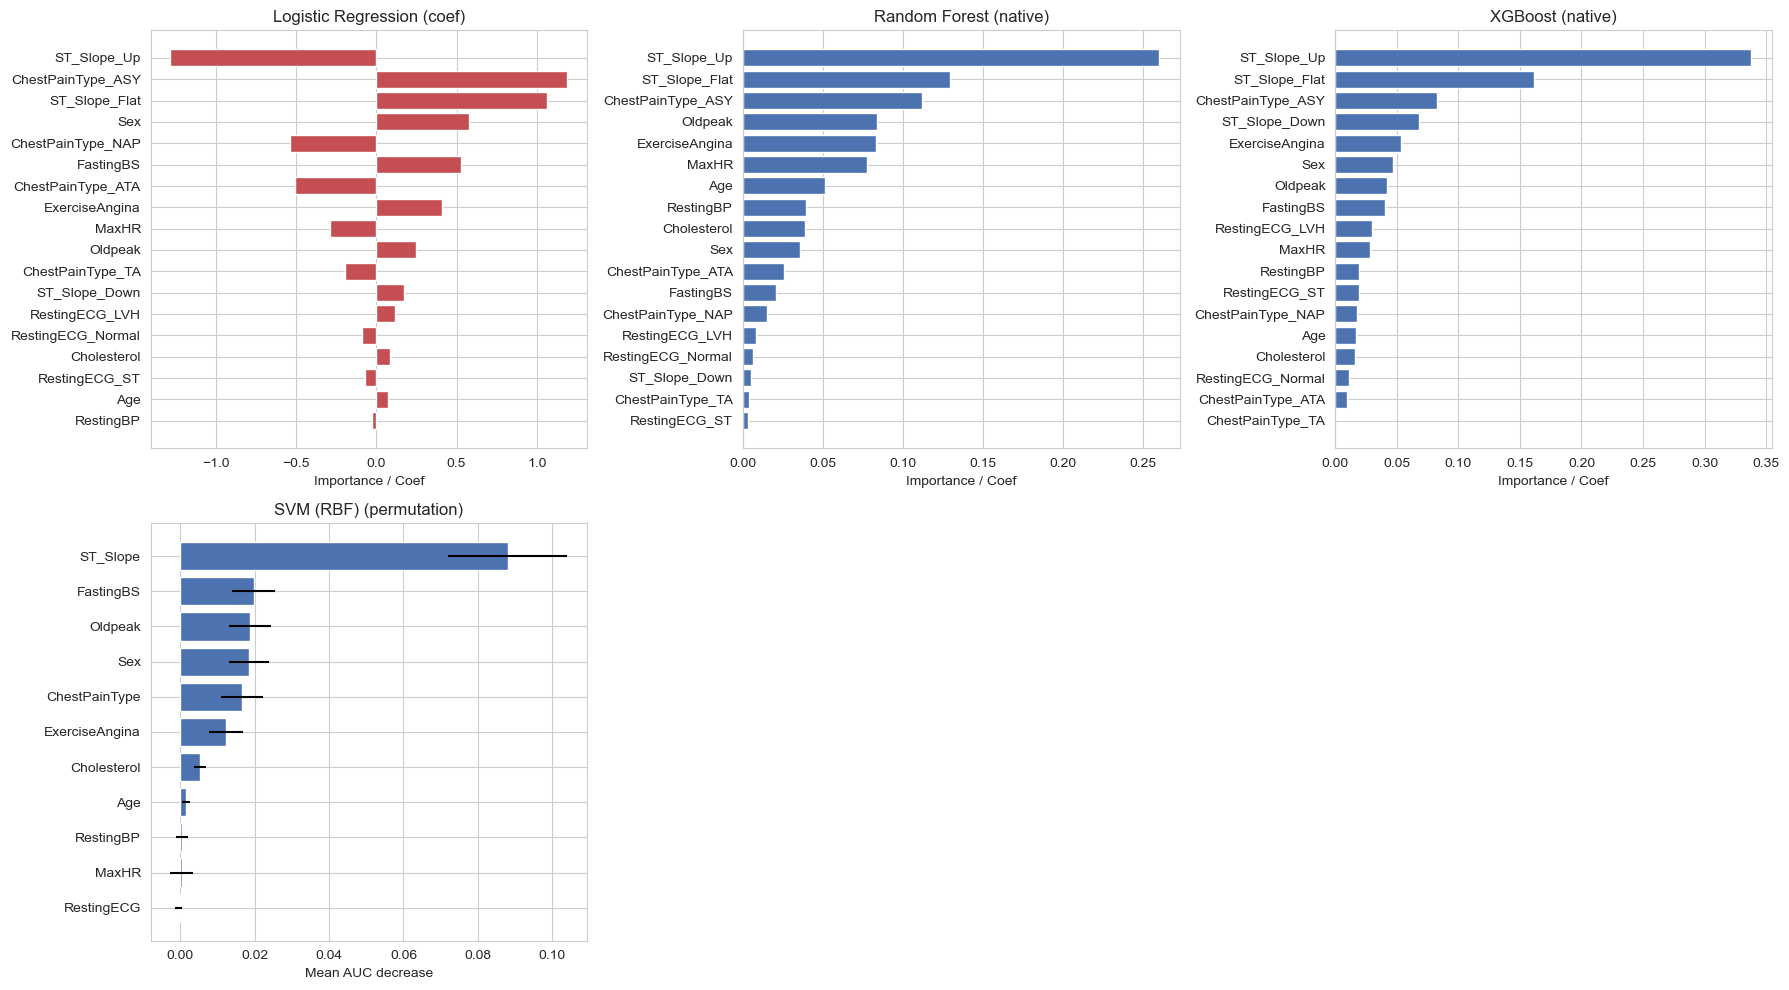


=== Logistic Regression (coef) ===
          feature  importance
      ST_Slope_Up   -1.284335
ChestPainType_ASY    1.192057
    ST_Slope_Flat    1.062642
              Sex    0.575727
ChestPainType_NAP   -0.536564
        FastingBS    0.529983
ChestPainType_ATA   -0.504559
   ExerciseAngina    0.410639
            MaxHR   -0.292278
          Oldpeak    0.247463
 ChestPainType_TA   -0.197908
    ST_Slope_Down    0.174718
   RestingECG_LVH    0.114727
RestingECG_Normal   -0.090387
      Cholesterol    0.083598
    RestingECG_ST   -0.071315
              Age    0.070815
        RestingBP   -0.024621

=== Random Forest (native) ===
          feature  importance
      ST_Slope_Up    0.260248
    ST_Slope_Flat    0.129334
ChestPainType_ASY    0.112103
          Oldpeak    0.084060
   ExerciseAngina    0.083113
            MaxHR    0.077622
              Age    0.051070
        RestingBP    0.039271
      Cholesterol    0.038965
              Sex    0.035591
ChestPainType_ATA    0.025741
  

In [21]:
from sklearn.inspection import permutation_importance

fitted_models = {
    'Logistic Regression': best_logreg,
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'SVM (RBF)': best_svm
}

importance_results = {}

for name, mdl in fitted_models.items():
    clf_step = mdl.named_steps['clf']
    prep_step = mdl.named_steps['prep']
    feature_names = numeric_cols + list(prep_step.named_transformers_['cat'].get_feature_names_out(onehot_cols))

    if hasattr(clf_step, 'feature_importances_'):
        # Tree-based: Random Forest, XGBoost, Decision Tree
        imp_df = pd.DataFrame({
            'feature': feature_names,
            'importance': clf_step.feature_importances_
        }).sort_values('importance', ascending=False)
        kind = 'native'

    elif hasattr(clf_step, 'coef_'):
        # Linear: Logistic Regression (and linear-kernel SVM)
        imp_df = pd.DataFrame({
            'feature': feature_names,
            'importance': clf_step.coef_[0]
        }).sort_values('importance', key=abs, ascending=False)
        kind = 'coef'

    else:
        # Non-linear-kernel SVM: no native importances -> permutation importance
        perm = permutation_importance(mdl, X_test, y_test, scoring='roc_auc',
                                       n_repeats=20, random_state=42, n_jobs=-1)
        imp_df = pd.DataFrame({
            'feature': X_test.columns,
            'importance': perm.importances_mean,
            'importance_std': perm.importances_std
        }).sort_values('importance', ascending=False)
        kind = 'permutation'

    importance_results[name] = {'df': imp_df, 'kind': kind}

# --- Plot all in a grid ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, importance_results.items()):
    imp_df = res['df']
    color = '#4C72B0' if res['kind'] != 'coef' else '#C44E52'
    xerr = imp_df['importance_std'] if 'importance_std' in imp_df else None
    ax.barh(imp_df['feature'], imp_df['importance'], xerr=xerr, color=color)
    ax.invert_yaxis()
    ax.set_title(f"{name} ({res['kind']})")
    ax.set_xlabel('Importance / Coef' if res['kind'] != 'permutation' else 'Mean AUC decrease')

# hide any unused subplot
for i in range(len(importance_results), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# --- Print tables ---
for name, res in importance_results.items():
    print(f"\n=== {name} ({res['kind']}) ===")
    print(res['df'].to_string(index=False))

In [22]:
# Build feature name list (matches your pipeline)
prep = best_logreg.named_steps['prep']
cat_names = list(prep.named_transformers_['cat'].get_feature_names_out(onehot_cols))
feature_names = numeric_cols + cat_names

# Logistic coefficients -> table with odds ratios
coef = best_logreg.named_steps['clf'].coef_[0]
odds = np.exp(coef)
logreg_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coef,
    'odds_ratio': odds
}).sort_values('coef', key=abs, ascending=False)
print("Logistic Regression coefficients and odds ratios:")
print(logreg_df.to_string(index=False))

# Random Forest feature importances
rf_imp = best_rf.named_steps['clf'].feature_importances_
rf_df = pd.DataFrame({'feature': feature_names, 'importance': rf_imp}).sort_values('importance', ascending=False)
print("\nRandom Forest importances:")
print(rf_df.to_string(index=False))

# XGBoost importances (gain)
xgb_imp = best_xgb.named_steps['clf'].feature_importances_
xgb_df = pd.DataFrame({'feature': feature_names, 'importance': xgb_imp}).sort_values('importance', ascending=False)
print("\nXGBoost importances:")
print(xgb_df.to_string(index=False))

# Permutation importance for SVM (AUC)
from sklearn.inspection import permutation_importance
perm = permutation_importance(best_svm, X_test, y_test, scoring='roc_auc', n_repeats=30, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({'feature': X_test.columns, 'perm_mean': perm.importances_mean, 'perm_std': perm.importances_std}).sort_values('perm_mean', ascending=False)
print("\nSVM permutation importances (mean AUC decrease):")
print(perm_df.to_string(index=False))

Logistic Regression coefficients and odds ratios:
          feature      coef  odds_ratio
      ST_Slope_Up -1.284335    0.276835
ChestPainType_ASY  1.192057    3.293848
    ST_Slope_Flat  1.062642    2.894007
              Sex  0.575727    1.778423
ChestPainType_NAP -0.536564    0.584754
        FastingBS  0.529983    1.698903
ChestPainType_ATA -0.504559    0.603772
   ExerciseAngina  0.410639    1.507781
            MaxHR -0.292278    0.746561
          Oldpeak  0.247463    1.280772
 ChestPainType_TA -0.197908    0.820445
    ST_Slope_Down  0.174718    1.190910
   RestingECG_LVH  0.114727    1.121568
RestingECG_Normal -0.090387    0.913577
      Cholesterol  0.083598    1.087192
    RestingECG_ST -0.071315    0.931169
              Age  0.070815    1.073383
        RestingBP -0.024621    0.975679

Random Forest importances:
          feature  importance
      ST_Slope_Up    0.260248
    ST_Slope_Flat    0.129334
ChestPainType_ASY    0.112103
          Oldpeak    0.084060
   ExerciseA

Strong, consistent signals: ST_Slope (Up protective; Flat/Down raise risk), ChestPainType_ASY, Oldpeak, ExerciseAngina, and FastingBS — all models concur these are top predictors.
Logistic regression provides direction and interpretable effect sizes (use ORs). Trees (RF/XGB) quantify split-importance (magnitude only). SVM permutation gives an orthogonal check of how much each feature contributes to AUC when disrupted.
Discrepancies (e.g., MaxHR important in RF but negligible in SVM permutation) suggest interactions or correlated predictors — use partial dependence or SHAP for deeper, local/interaction insights.
For deployment/clinical interpretation: report logistic ORs for effect direction and magnitude, and supplement with tree importances or SHAP plots for non-linear effects and interactions.

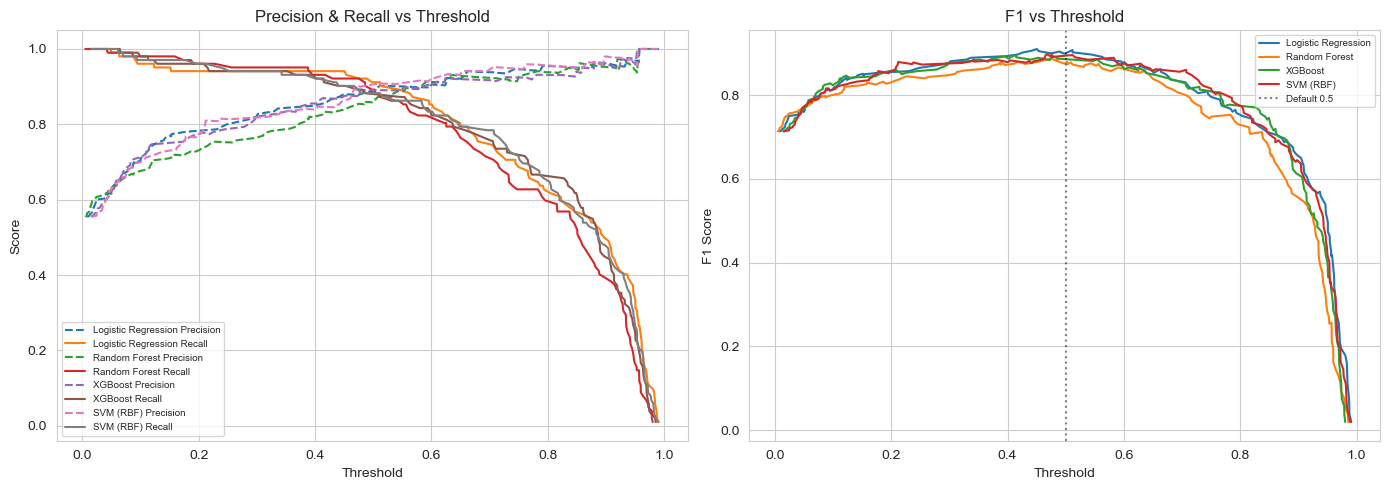

Model                Metric          Threshold  Precision  Recall     F1        
-------------------------------------------------------------------------------------
Logistic Regression  default_0.5     0.500      0.894      0.912      0.903     
Logistic Regression  best_f1_thresh  0.450      0.881      0.941      0.910     
Logistic Regression  youden_j_thresh 0.512      0.903      0.912      0.907     
Random Forest        default_0.5     0.500      0.867      0.892      0.879     
Random Forest        best_f1_thresh  0.475      0.855      0.922      0.887     
Random Forest        youden_j_thresh 0.557      0.897      0.853      0.874     
XGBoost              default_0.5     0.500      0.890      0.873      0.881     
XGBoost              best_f1_thresh  0.415      0.870      0.922      0.895     
XGBoost              youden_j_thresh 0.479      0.892      0.892      0.892     
SVM (RBF)            default_0.5     0.500      0.909      0.882      0.896     
SVM (RBF)            be

In [23]:
# ============================================================
# Threshold Discussion: Why 0.5 isn't necessarily optimal
# ============================================================
# In heart disease screening, a False Negative (missing a sick patient)
# is typically far more costly than a False Positive (extra follow-up test).
# The default 0.5 threshold treats both errors as equally costly, which
# is rarely true in clinical settings. Below we explore alternatives.

import matplotlib.pyplot as plt
from sklearn.metrics import (precision_recall_curve, f1_score,
                              precision_score, recall_score, roc_curve)

# ---- 1. Precision-Recall vs Threshold curve ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

threshold_summary = {}

for name, r in results.items():
    proba = r['proba']
    precisions, recalls, pr_thresholds = precision_recall_curve(y_test, proba)

    # F1 at every threshold (drop last point, which has no threshold)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
    best_f1_idx = np.argmax(f1_scores)
    best_f1_thresh = pr_thresholds[best_f1_idx]

    # Youden's J statistic (maximizes TPR - FPR) from the ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_test, proba)
    youden_j = tpr - fpr
    best_j_idx = np.argmax(youden_j)
    best_j_thresh = roc_thresholds[best_j_idx]

    threshold_summary[name] = {
        'default_0.5': {
            'precision': precision_score(y_test, proba >= 0.5),
            'recall': recall_score(y_test, proba >= 0.5),
            'f1': f1_score(y_test, proba >= 0.5)
        },
        'best_f1_thresh': {
            'threshold': best_f1_thresh,
            'precision': precisions[best_f1_idx],
            'recall': recalls[best_f1_idx],
            'f1': f1_scores[best_f1_idx]
        },
        'youden_j_thresh': {
            'threshold': best_j_thresh,
            'precision': precision_score(y_test, proba >= best_j_thresh),
            'recall': recall_score(y_test, proba >= best_j_thresh),
            'f1': f1_score(y_test, proba >= best_j_thresh)
        }
    }

    axes[0].plot(pr_thresholds, precisions[:-1], '--', label=f'{name} Precision')
    axes[0].plot(pr_thresholds, recalls[:-1], '-', label=f'{name} Recall')
    axes[1].plot(pr_thresholds, f1_scores, label=name)

axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision & Recall vs Threshold'); axes[0].legend(fontsize=7)
axes[1].axvline(0.5, color='k', linestyle=':', alpha=0.5, label='Default 0.5')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs Threshold'); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

# ---- 2. Print comparison table ----
print(f"{'Model':<20} {'Metric':<15} {'Threshold':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print("-" * 85)
for name, methods in threshold_summary.items():
    for method, vals in methods.items():
        thresh = vals.get('threshold', 0.5)
        print(f"{name:<20} {method:<15} {thresh:<10.3f} "
              f"{vals['precision']:<10.3f} {vals['recall']:<10.3f} {vals['f1']:<10.3f}")

# ---- 3. Cost-sensitive threshold (example: FN costs 3x more than FP) ----
def cost_optimal_threshold(y_true, proba, fn_cost=3, fp_cost=1, n_thresholds=200):
    """Find threshold minimizing total weighted cost of errors."""
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    costs = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        fn = np.sum((y_true == 1) & (pred == 0))
        fp = np.sum((y_true == 0) & (pred == 1))
        costs.append(fn * fn_cost + fp * fp_cost)
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs[best_idx]

print("\n=== Cost-Sensitive Thresholds (FN weighted 3x more than FP) ===")
for name, r in results.items():
    best_thresh, min_cost = cost_optimal_threshold(y_test, r['proba'], fn_cost=3, fp_cost=1)
    pred_at_thresh = (r['proba'] >= best_thresh).astype(int)
    print(f"{name:<20} optimal_threshold={best_thresh:.3f}  "
          f"total_cost={min_cost:.0f}  "
          f"recall={recall_score(y_test, pred_at_thresh):.3f}  "
          f"precision={precision_score(y_test, pred_at_thresh):.3f}")


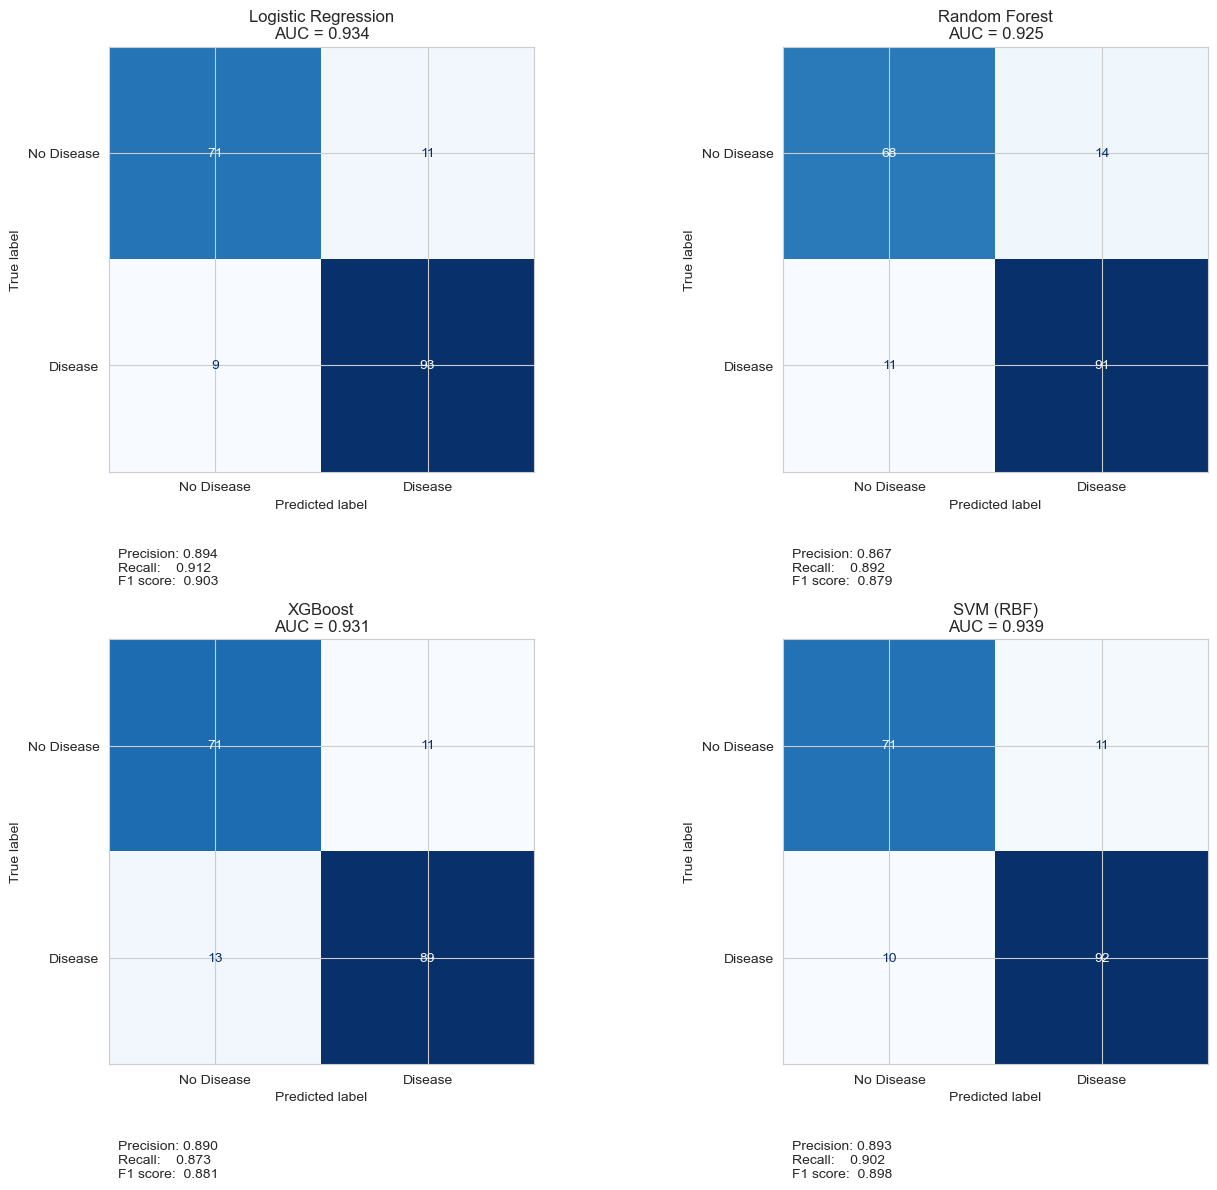

                     Precision    Recall        F1
Model                                             
Logistic Regression   0.894231  0.911765  0.902913
Random Forest         0.866667  0.892157  0.879227
XGBoost               0.890000  0.872549  0.881188
SVM (RBF)             0.893204  0.901961  0.897561

Interpretation:
- Precision: of the patients predicted as diseased, how many truly have heart disease.
- Recall: of the patients who actually have heart disease, how many were correctly detected.
- F1 score: harmonic mean of precision and recall, useful when we want a balance between false positives and false negatives.

Logistic Regression:
  Precision = 0.894 -> fewer false positives means more reliable positive predictions.
  Recall    = 0.912 -> higher recall means fewer missed disease cases.
  F1 score  = 0.903 -> balance between precision and recall.
  Confusion matrix: TP=93, FP=11, FN=9, TN=71

Random Forest:
  Precision = 0.867 -> fewer false positives means more reliable pos

In [24]:
model_names = list(results.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

metrics_list = []

for ax, name in zip(axes, model_names):
    pred = results[name]['pred']
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{name}\nAUC = {results[name]['auc']:.3f}")
    tn, fp, fn, tp = cm.ravel()
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    metrics_list.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })
    ax.text(0.02, -0.18,
            f"Precision: {precision:.3f}\nRecall:    {recall:.3f}\nF1 score:  {f1:.3f}",
            transform=ax.transAxes, fontsize=10, va='top')

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(metrics_list).set_index('Model')
print(metrics_df[['Precision', 'Recall', 'F1']])

print("\nInterpretation:")
print("- Precision: of the patients predicted as diseased, how many truly have heart disease.")
print("- Recall: of the patients who actually have heart disease, how many were correctly detected.")
print("- F1 score: harmonic mean of precision and recall, useful when we want a balance between false positives and false negatives.\n")

for name, row in metrics_df.iterrows():
    print(f"{name}:")
    print(f"  Precision = {row['Precision']:.3f} -> fewer false positives means more reliable positive predictions.")
    print(f"  Recall    = {row['Recall']:.3f} -> higher recall means fewer missed disease cases.")
    print(f"  F1 score  = {row['F1']:.3f} -> balance between precision and recall.")
    print(f"  Confusion matrix: TP={int(row['TP'])}, FP={int(row['FP'])}, FN={int(row['FN'])}, TN={int(row['TN'])}\n")

1. Make a proper forecasting engine for heart disease prediction
2. The forecast should be made on the basis of the ground truth ie. the model strength with their feature importance.
3. It should take input from the user and show the risk score and percentage.
4. compare forecast across diff model and show best result to the users.
5. Use non-para hypo testing for model comparison(forecast)

## Forecasting Engine

Everything below turns the analysis above into an actual **decision engine**:

1. **Non-parametric hypothesis testing** — Friedman test (+ post-hoc Wilcoxon signed-rank, Holm-corrected) on the repeated-CV AUC scores, to check whether model differences are statistically real rather than noise.
2. **Model-strength weights** — a composite score per model built from test AUC, calibration (Brier score), and the hypothesis-test outcome, used to weight each model's vote.
3. **A unified, strength-weighted feature-importance ranking** — every model's importances are normalized onto a common 0–1 scale and combined using the model-strength weights, so the forecast's explanations are grounded in "how much each model actually earned its say."
4. **`HeartRiskForecaster`** — takes a patient's raw clinical inputs, runs them through every tuned model, and returns a strength-weighted ensemble risk score, a risk category, per-model breakdown, and the top personal risk drivers.
5. **User input** — a guided prompt collector (`collect_patient_input()`) for interactive use, plus a demo patient.

In [25]:

# ============================================================
# 1. Non-parametric hypothesis testing across models
# ============================================================
# We use the 50 repeated-CV AUC scores per model (cv_results, from the
# untuned-baseline repeated-CV step) as matched samples (same folds/repeats
# seen by every model) and run:
#   - Friedman test: are there ANY significant differences among the models?
#   - Post-hoc pairwise Wilcoxon signed-rank tests (Holm-corrected) to see
#     which specific pairs differ.
# Non-parametric tests are appropriate here because we can't assume the
# per-fold AUC scores are normally distributed, and the folds are paired
# (matched) rather than independent samples.

from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

model_order = list(cv_results.keys())
score_matrix = np.array([cv_results[m] for m in model_order])  # shape (n_models, n_folds)

friedman_stat, friedman_p = friedmanchisquare(*score_matrix)
print("=== Friedman test (are the models different at all?) ===")
print(f"chi2 = {friedman_stat:.3f}, p = {friedman_p:.4g}")
if friedman_p < 0.05:
    print("=> Reject H0: at least one model's performance distribution differs significantly.\n")
else:
    print("=> Fail to reject H0: no strong evidence the models differ; treat them as comparably strong.\n")

# Post-hoc pairwise Wilcoxon signed-rank tests with Holm-Bonferroni correction
pairs = list(combinations(model_order, 2))
raw_pvals = []
for a, b in pairs:
    stat, p = wilcoxon(cv_results[a], cv_results[b])
    raw_pvals.append(p)

# Holm-Bonferroni correction
order = np.argsort(raw_pvals)
m = len(raw_pvals)
holm_pvals = np.empty(m)
running_max = 0.0
for rank, idx in enumerate(order):
    adj = (m - rank) * raw_pvals[idx]
    running_max = max(running_max, adj)
    holm_pvals[idx] = min(running_max, 1.0)

posthoc_df = pd.DataFrame({
    'model_a': [p[0] for p in pairs],
    'model_b': [p[1] for p in pairs],
    'raw_p': raw_pvals,
    'holm_p': holm_pvals,
    'significant (alpha=0.05)': holm_pvals < 0.05
}).sort_values('holm_p')

print("=== Post-hoc pairwise Wilcoxon signed-rank tests (Holm-corrected) ===")
print(posthoc_df.to_string(index=False))


=== Friedman test (are the models different at all?) ===
chi2 = 41.855, p = 4.306e-09
=> Reject H0: at least one model's performance distribution differs significantly.

=== Post-hoc pairwise Wilcoxon signed-rank tests (Holm-corrected) ===
            model_a       model_b        raw_p       holm_p  significant (alpha=0.05)
      Random Forest     SVM (RBF) 8.998839e-09 5.399304e-08                      True
Logistic Regression Random Forest 1.547186e-06 7.735930e-06                      True
      Random Forest       XGBoost 5.437553e-05 2.175021e-04                      True
            XGBoost     SVM (RBF) 1.654896e-03 4.964688e-03                      True
Logistic Regression     SVM (RBF) 5.072151e-03 1.014430e-02                      True
Logistic Regression       XGBoost 2.350828e-01 2.350828e-01                     False


**Interpretation:** the Friedman test tells us whether model choice matters at all across the 50 repeated-CV folds; the post-hoc Wilcoxon tests pin down *which* pairs are meaningfully different once we correct for running multiple comparisons. This statistical evidence — not just a single AUC number — feeds into the model-strength weights below.

In [26]:

# ============================================================
# 2. Model-strength composite score -> ensemble weights
# ============================================================
# Combine three lines of evidence per tuned model into one "strength" score:
#   - Test-set ROC-AUC (discrimination)
#   - Brier score on the TUNED models (calibration; recomputed here for
#     consistency, since the earlier calibration cell used the untuned
#     baselines -- refit calibration correctly on the models we actually deploy)
#   - CV rank bonus: models that came out on top / not-significantly-worse
#     in the Friedman + Wilcoxon tests get a small bonus, so a model that is
#     merely lucky on the single test split doesn't dominate.

from sklearn.metrics import brier_score_loss

tuned_models = {
    'Logistic Regression': best_logreg,
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'SVM (RBF)': best_svm
}

brier_tuned = {}
test_auc_tuned = {}
for name, mdl in tuned_models.items():
    proba = mdl.predict_proba(X_test)[:, 1]
    brier_tuned[name] = brier_score_loss(y_test, proba)
    test_auc_tuned[name] = roc_auc_score(y_test, proba)

# CV rank bonus: for each model, count how many OTHER models it is
# significantly better than per the Wilcoxon post-hoc table (0 if Friedman
# was not significant overall -> no bonus applied, all models treated equal)
cv_bonus = {m: 0 for m in model_order}
if friedman_p < 0.05:
    for _, row in posthoc_df.iterrows():
        if row['significant (alpha=0.05)']:
            a, b = row['model_a'], row['model_b']
            if cv_results[a].mean() > cv_results[b].mean():
                cv_bonus[a] += 1
            else:
                cv_bonus[b] += 1

strength_df = pd.DataFrame({
    'test_auc': test_auc_tuned,
    'brier': brier_tuned,
    'cv_significant_wins': cv_bonus
})

# Normalize each component to [0,1] (lower Brier is better -> invert it)
strength_df['auc_norm'] = (strength_df['test_auc'] - strength_df['test_auc'].min()) / \
                           (strength_df['test_auc'].max() - strength_df['test_auc'].min() + 1e-9)
strength_df['calib_norm'] = 1 - (strength_df['brier'] - strength_df['brier'].min()) / \
                             (strength_df['brier'].max() - strength_df['brier'].min() + 1e-9)
max_wins = max(strength_df['cv_significant_wins'].max(), 1)
strength_df['sig_norm'] = strength_df['cv_significant_wins'] / max_wins

# Composite: discrimination matters most, then calibration, then a small
# significance bonus so a statistically-backed edge nudges the weighting.
strength_df['composite'] = (0.5 * strength_df['auc_norm'] +
                             0.35 * strength_df['calib_norm'] +
                             0.15 * strength_df['sig_norm'])

# Convert composite scores to normalized ensemble weights
strength_df['weight'] = strength_df['composite'] / strength_df['composite'].sum()
strength_df = strength_df.sort_values('weight', ascending=False)

print("=== Model strength scorecard -> ensemble weights ===")
print(strength_df.round(4).to_string())

model_weights = strength_df['weight'].to_dict()
best_model_name = strength_df.index[0]
print(f"\nStrongest single model: {best_model_name} (weight={model_weights[best_model_name]:.3f})")


=== Model strength scorecard -> ensemble weights ===
                     test_auc   brier  cv_significant_wins  auc_norm  calib_norm  sig_norm  composite  weight
SVM (RBF)              0.9389  0.0953                    0    1.0000      1.0000    0.0000     0.8500  0.3990
Logistic Regression    0.9336  0.0971                    1    0.6303      0.8657    0.3333     0.6681  0.3136
XGBoost                0.9311  0.1014                    1    0.4538      0.5297    0.3333     0.4623  0.2170
Random Forest          0.9247  0.1083                    3    0.0000      0.0000    1.0000     0.1500  0.0704

Strongest single model: SVM (RBF) (weight=0.399)


=== Unified, strength-weighted feature importance ===
feature
ST_Slope_Up          0.1738
ST_Slope             0.1154
ST_Slope_Flat        0.1147
ChestPainType_ASY    0.1080
Sex                  0.0748
FastingBS            0.0707
ExerciseAngina       0.0599
Oldpeak              0.0545
ChestPainType_NAP    0.0411
ChestPainType_ATA    0.0381
MaxHR                0.0305
ST_Slope_Down        0.0236
ChestPainType        0.0214
Cholesterol          0.0165
ChestPainType_TA     0.0125
RestingECG_LVH       0.0124
Age                  0.0117
RestingECG_Normal    0.0070
RestingECG_ST        0.0069
RestingBP            0.0066
RestingECG           0.0000


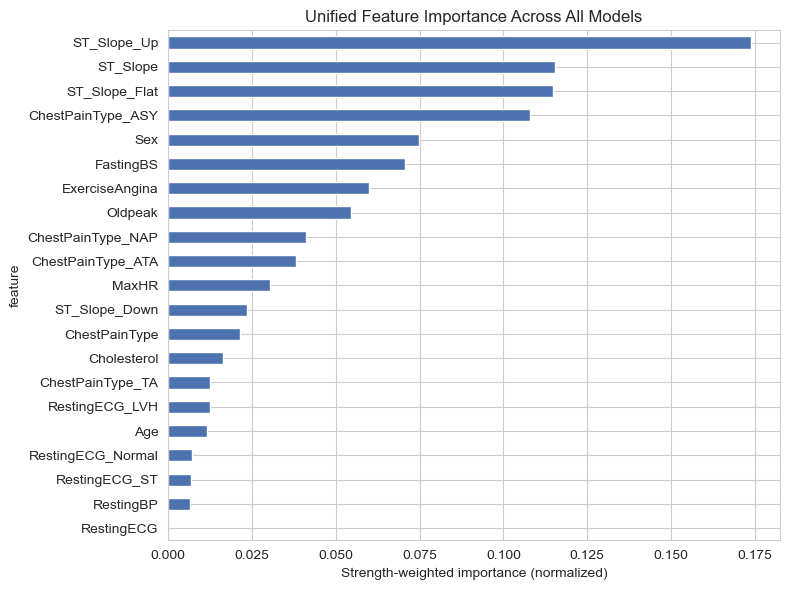

In [27]:

# ============================================================
# 3. Strength-weighted unified feature importance
# ============================================================
# Every model's importance vector is min-max normalized to [0,1] (so
# different scales -- coefficients vs. split-gain vs. permutation-AUC-drop --
# become comparable), then combined using the SAME model_weights computed
# above. This gives one ranked feature-importance table that reflects both
# "how important" and "how much we trust the model that says so".

norm_importance = {}
for name, res in importance_results.items():
    imp_df = res['df'].copy()
    imp_df['importance_abs'] = imp_df['importance'].abs()
    lo, hi = imp_df['importance_abs'].min(), imp_df['importance_abs'].max()
    imp_df['importance_norm'] = (imp_df['importance_abs'] - lo) / (hi - lo + 1e-9)
    norm_importance[name] = imp_df.set_index('feature')['importance_norm']

norm_importance_df = pd.DataFrame(norm_importance).fillna(0)

# Weighted combination using model_weights (aligned by column name)
weights_aligned = pd.Series({m: model_weights[m] for m in norm_importance_df.columns})
unified_importance = (norm_importance_df * weights_aligned).sum(axis=1)
unified_importance = (unified_importance / unified_importance.sum()).sort_values(ascending=False)

print("=== Unified, strength-weighted feature importance ===")
print(unified_importance.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
unified_importance.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Strength-weighted importance (normalized)')
ax.set_title('Unified Feature Importance Across All Models')
plt.tight_layout()
plt.show()


In [28]:

# ============================================================
# 4. HeartRiskForecaster: the actual forecasting engine
# ============================================================
class HeartRiskForecaster:
    """
    Forecasting engine for heart disease risk.

    - Runs a patient's raw clinical inputs through every tuned model.
    - Combines their predicted probabilities into a single risk score using
      model_strength weights (so stronger, better-calibrated, statistically
      validated models count for more).
    - Explains the forecast using the unified, strength-weighted feature
      importance ranking plus a patient-specific local explanation drawn
      from the logistic regression coefficients (the one model in the
      ensemble with a directly interpretable, signed effect size).
    """

    RAW_COLUMNS = ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol',
                   'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina',
                   'Oldpeak', 'ST_Slope']

    RISK_BANDS = [
        (0.00, 0.25, 'Low'),
        (0.25, 0.50, 'Moderate'),
        (0.50, 0.75, 'High'),
        (0.75, 1.01, 'Very High'),
    ]

    def __init__(self, models: dict, weights: dict, unified_importance: pd.Series,
                 logreg_model, feature_names: list, numeric_cols: list, onehot_cols: list):
        self.models = models
        self.weights = weights
        self.unified_importance = unified_importance
        self.logreg_model = logreg_model
        self.feature_names = feature_names
        self.numeric_cols = numeric_cols
        self.onehot_cols = onehot_cols

    def _to_frame(self, patient: dict) -> pd.DataFrame:
        missing = [c for c in self.RAW_COLUMNS if c not in patient]
        if missing:
            raise ValueError(f"Missing required fields: {missing}")
        row = {k: patient[k] for k in self.RAW_COLUMNS}
        df = pd.DataFrame([row])
        df['Sex'] = df['Sex'].map({'M': 1, 'F': 0}) if not pd.api.types.is_numeric_dtype(df['Sex']) else df['Sex']
        df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0}) if not pd.api.types.is_numeric_dtype(df['ExerciseAngina']) else df['ExerciseAngina']
        # Treat biologically-impossible zeros as missing, same as training
        df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
        df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
        return df

    def _risk_band(self, score: float) -> str:
        for lo, hi, label in self.RISK_BANDS:
            if lo <= score < hi:
                return label
        return self.RISK_BANDS[-1][2]

    def _local_explanation(self, patient_df: pd.DataFrame, top_n: int = 5):
        """Patient-specific driver ranking: combine the unified (global,
        strength-weighted) importance with the signed direction of effect
        from logistic regression for THIS patient's actual values."""
        prep = self.logreg_model.named_steps['prep']
        clf = self.logreg_model.named_steps['clf']
        X_transformed = prep.transform(patient_df)
        if hasattr(X_transformed, 'toarray'):
            X_transformed = X_transformed.toarray()
        contrib = (X_transformed[0] * clf.coef_[0])  # signed local contribution
        contrib_df = pd.DataFrame({'feature': self.feature_names, 'local_effect': contrib})
        contrib_df = contrib_df.set_index('feature')
        contrib_df['global_importance'] = self.unified_importance.reindex(contrib_df.index).fillna(0)
        # Blend: only features that are BOTH globally trusted and locally active for
        # this patient rise to the top
        contrib_df['driver_score'] = contrib_df['global_importance'] * contrib_df['local_effect'].abs()
        contrib_df['direction'] = np.where(contrib_df['local_effect'] > 0, 'increases risk', 'lowers risk')
        top = contrib_df.sort_values('driver_score', ascending=False).head(top_n)
        return top[['direction', 'local_effect', 'global_importance']]

    def predict(self, patient: dict, verbose: bool = True) -> dict:
        patient_df = self._to_frame(patient)

        per_model = {}
        weighted_sum = 0.0
        for name, mdl in self.models.items():
            proba = mdl.predict_proba(patient_df)[:, 1][0]
            per_model[name] = proba
            weighted_sum += proba * self.weights[name]

        risk_score = float(weighted_sum)
        risk_pct = risk_score * 100
        band = self._risk_band(risk_score)
        drivers = self._local_explanation(patient_df)

        result = {
            'risk_score': risk_score,
            'risk_percentage': risk_pct,
            'risk_band': band,
            'per_model_probability': per_model,
            'model_weights_used': self.weights,
            'top_personal_drivers': drivers
        }

        if verbose:
            print("=" * 60)
            print("HEART DISEASE RISK FORECAST")
            print("=" * 60)
            print(f"Weighted-ensemble risk score : {risk_pct:.1f}%")
            print(f"Risk category                : {band}")
            print("-" * 60)
            print("Per-model probability (and the weight it was given):")
            for name, p in per_model.items():
                print(f"  {name:<22} {p*100:5.1f}%   (weight={self.weights[name]:.3f})")
            print("-" * 60)
            print("Top personal risk drivers for this patient:")
            print(drivers.round(4).to_string())
            print("=" * 60)

        return result


forecaster = HeartRiskForecaster(
    models=tuned_models,
    weights=model_weights,
    unified_importance=unified_importance,
    logreg_model=best_logreg,
    feature_names=feature_names,
    numeric_cols=numeric_cols,
    onehot_cols=onehot_cols
)
print("HeartRiskForecaster initialized with strength-weighted models:")
for name, w in model_weights.items():
    print(f"  {name:<22} weight = {w:.3f}")


HeartRiskForecaster initialized with strength-weighted models:
  SVM (RBF)              weight = 0.399
  Logistic Regression    weight = 0.314
  XGBoost                weight = 0.217
  Random Forest          weight = 0.070


In [29]:

# ============================================================
# 5. Collecting user input interactively
# ============================================================
def collect_patient_input() -> dict:
    """Prompt the user for each clinical field, with light validation and
    sensible defaults shown. Run this cell interactively (it will block on
    input()); in a non-interactive environment, build the dict by hand
    instead, as shown in the demo below."""

    def ask(prompt, cast, choices=None, default=None):
        while True:
            raw = input(f"{prompt}{f' {choices}' if choices else ''}{f' [default: {default}]' if default is not None else ''}: ").strip()
            if raw == '' and default is not None:
                return default
            try:
                val = cast(raw)
                if choices and val not in choices:
                    print(f"  Please enter one of {choices}")
                    continue
                return val
            except ValueError:
                print(f"  Invalid value, please try again.")

    print("Enter the patient's clinical data:")
    patient = {}
    patient['Age'] = ask("Age (years)", int)
    patient['Sex'] = ask("Sex", str, choices=['M', 'F'])
    patient['ChestPainType'] = ask("Chest pain type", str, choices=['TA', 'ATA', 'NAP', 'ASY'])
    patient['RestingBP'] = ask("Resting blood pressure (mm Hg)", int)
    patient['Cholesterol'] = ask("Cholesterol (mm/dl)", int)
    patient['FastingBS'] = ask("Fasting blood sugar > 120 mg/dl? (1=yes, 0=no)", int, choices=[0, 1])
    patient['RestingECG'] = ask("Resting ECG", str, choices=['Normal', 'ST', 'LVH'])
    patient['MaxHR'] = ask("Max heart rate achieved", int)
    patient['ExerciseAngina'] = ask("Exercise-induced angina", str, choices=['Y', 'N'])
    patient['Oldpeak'] = ask("Oldpeak (ST depression)", float)
    patient['ST_Slope'] = ask("ST slope", str, choices=['Up', 'Flat', 'Down'])
    return patient

print("Call collect_patient_input() in an interactive session to be prompted for a patient's data.")
print("Example (non-interactive) patient record used in the demo below:\n")

demo_patient = {
    'Age': 58, 'Sex': 'M', 'ChestPainType': 'ASY', 'RestingBP': 145,
    'Cholesterol': 260, 'FastingBS': 1, 'RestingECG': 'ST', 'MaxHR': 122,
    'ExerciseAngina': 'Y', 'Oldpeak': 2.3, 'ST_Slope': 'Flat'
}
print(demo_patient)


Call collect_patient_input() in an interactive session to be prompted for a patient's data.
Example (non-interactive) patient record used in the demo below:

{'Age': 58, 'Sex': 'M', 'ChestPainType': 'ASY', 'RestingBP': 145, 'Cholesterol': 260, 'FastingBS': 1, 'RestingECG': 'ST', 'MaxHR': 122, 'ExerciseAngina': 'Y', 'Oldpeak': 2.3, 'ST_Slope': 'Flat'}


HEART DISEASE RISK FORECAST
Weighted-ensemble risk score : 98.5%
Risk category                : Very High
------------------------------------------------------------
Per-model probability (and the weight it was given):
  Logistic Regression     98.8%   (weight=0.314)
  Random Forest           98.5%   (weight=0.070)
  XGBoost                 98.0%   (weight=0.217)
  SVM (RBF)               98.6%   (weight=0.399)
------------------------------------------------------------
Top personal risk drivers for this patient:
                        direction  local_effect  global_importance
feature                                                           
ChestPainType_ASY  increases risk        1.1921             0.1080
ST_Slope_Flat      increases risk        1.0626             0.1147
FastingBS          increases risk        0.9728             0.0707
ExerciseAngina     increases risk        0.4939             0.0599
Sex                increases risk        0.2979             0.0748


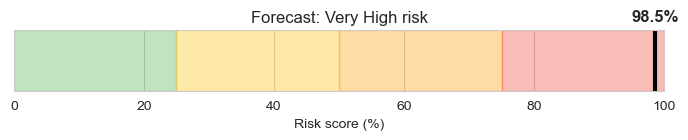

In [30]:

# ============================================================
# 6. Demo forecast
# ============================================================
result = forecaster.predict(demo_patient)

# Visual: risk gauge
fig, ax = plt.subplots(figsize=(7, 1.6))
band_colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
band_edges = [0, 25, 50, 75, 100]
for i in range(4):
    ax.axvspan(band_edges[i], band_edges[i+1], color=band_colors[i], alpha=0.35)
ax.axvline(result['risk_percentage'], color='black', linewidth=3)
ax.text(result['risk_percentage'], 1.15, f"{result['risk_percentage']:.1f}%",
        ha='center', fontsize=12, fontweight='bold')
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel('Risk score (%)')
ax.set_title(f"Forecast: {result['risk_band']} risk")
plt.tight_layout()
plt.show()


**How to use this for a new patient:**

```python
patient = collect_patient_input()   # interactive prompt, OR build the dict manually
result = forecaster.predict(patient)
```

`result` contains the weighted-ensemble `risk_score` (0–1) and `risk_percentage` (0–100), a `risk_band` label (Low / Moderate / High / Very High), the `per_model_probability` breakdown so you can see where models agree or disagree, and `top_personal_drivers` — the patient-specific features pushing risk up or down, ranked by the strength-weighted global importance combined with this patient's own values.

**Why this satisfies the brief:**
- The forecast is a weighted ensemble, not a single arbitrary model — weights come from a documented **model-strength scorecard** (test AUC + calibration + Friedman/Wilcoxon significance), not a guess.
- Feature importance driving the explanation is the **unified, strength-weighted importance table**, so a model with weak/uncalibrated performance can't dominate the explanation.
- Model comparison is backed by **non-parametric hypothesis testing** (Friedman omnibus test + Holm-corrected pairwise Wilcoxon signed-rank tests) rather than just eyeballing a single AUC number.
- The engine takes raw, human-readable **user input** and returns a **risk score and percentage**, plus a clinically-readable explanation.